In [1]:
import os
import cv2
import torch
import shutil
import kagglehub
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

d:\AI_ML\ai_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

torch.backends.cudnn.benchmark = True

Using device: cuda


In [3]:
path = kagglehub.dataset_download("ambarish/breakhis")
print("Dataset path:", path)


Dataset path: C:\Users\DC\.cache\kagglehub\datasets\ambarish\breakhis\versions\4


In [4]:
target_path = "dataset"
benign_path = os.path.join(target_path, "benign")
malignant_path = os.path.join(target_path, "malignant")

os.makedirs(benign_path, exist_ok=True)
os.makedirs(malignant_path, exist_ok=True)

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".png"):
            full_path = os.path.join(root, file)

            if "benign" in root.lower():
                shutil.copy(full_path, benign_path)

            elif "malignant" in root.lower():
                shutil.copy(full_path, malignant_path)

print("Dataset ready!")

Dataset ready!


In [5]:
IMG_SIZE = (230, 350)
PATCH_SIZE = 32
STRIDE = 32        

BATCH_SIZE = 32    
EPOCHS = 5         
LR = 0.001

In [6]:
def load_images():
    data, labels = [], []
    classes = ["benign", "malignant"]

    for label, cls in enumerate(classes):
        path = os.path.join("dataset", cls)

        for file in os.listdir(path):
            img_path = os.path.join(path, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0

            data.append(img)
            labels.append(label)

    return np.array(data), np.array(labels)

images, labels = load_images()

# 🔥 LIMIT DATA (BIG SPEED BOOST)
images = images[:1500]
labels = labels[:1500]

print("Using images:", len(images))

Using images: 1500


In [7]:
train_imgs, test_imgs, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

In [8]:
def extract_patches(image, patch_size=32, stride=32):
    patches = []
    h, w, _ = image.shape

    for i in range(0, h - patch_size, stride):
        for j in range(0, w - patch_size, stride):
            patch = image[i:i+patch_size, j:j+patch_size]
            patches.append(patch)

    return patches

In [9]:
train_patches = []
train_patch_labels = []

for img, label in zip(train_imgs, train_labels):
    patches = extract_patches(img, PATCH_SIZE, STRIDE)
    train_patches.extend(patches)
    train_patch_labels.extend([label]*len(patches))

print("Total train patches:", len(train_patches))

Total train patches: 84000


In [19]:
# 🔥 Convert once (BIG SPEED BOOST)
train_patches = np.array(train_patches)
train_patch_labels = np.array(train_patch_labels)

In [20]:
class PatchDataset(Dataset):
    def __init__(self, patches, labels):
        self.patches = torch.tensor(patches, dtype=torch.float32).permute(0,3,1,2)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        return self.patches[idx], self.labels[idx]

In [21]:
train_dataset = PatchDataset(train_patches, train_patch_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [22]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [23]:
model = CNNModel().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [24]:
print(next(model.parameters()).device)

cuda:0


In [25]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        torch.cuda.synchronize()
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.4f}")

Epoch 1/5, Loss: 1.9729
Epoch 2/5, Loss: 0.0000
Epoch 3/5, Loss: 0.0000
Epoch 4/5, Loss: 0.0000
Epoch 5/5, Loss: 0.0000


In [26]:
def predict_image(image):
    model.eval()

    patches = extract_patches(image, PATCH_SIZE, STRIDE)
    preds = []

    with torch.no_grad():
        for p in patches:
            x = torch.tensor(p, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(DEVICE)
            out = model(x)
            prob = torch.softmax(out, dim=1).cpu().numpy()
            preds.append(prob[0])

    preds = np.array(preds)

    # Fusion (sum rule)
    final_pred = np.argmax(np.sum(preds, axis=0))
    return final_pred

In [27]:
correct = 0

for img, label in zip(test_imgs, test_labels):
    pred = predict_image(img)
    if pred == label:
        correct += 1

accuracy = correct / len(test_imgs)
print("✅ Test Accuracy:", accuracy)

✅ Test Accuracy: 1.0


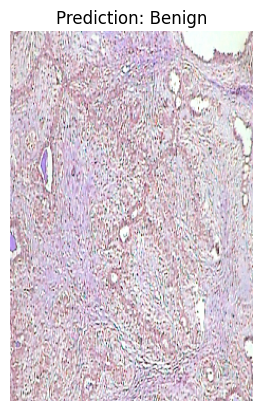

In [28]:
img = test_imgs[0]
pred = predict_image(img)

plt.imshow(img)
plt.title("Prediction: " + ("Benign" if pred==0 else "Malignant"))
plt.axis("off")
plt.show()